In [158]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
plt.style.use('ggplot')

from sklearn.ensemble import HistGradientBoostingRegressor

from cluster_experiments.random_splitter import (
    SwitchbackSplitter,
    Washover
)
from cluster_experiments.power_analysis import PowerAnalysis
from cluster_experiments.power_analysis import NormalPowerAnalysis
from cluster_experiments import (
    ClusteredSplitter,
    ConstantPerturbator,
    ClusteredOLSAnalysis,
    PowerAnalysis,
    AnalysisPlan,
    SimpleMetric,
    Dimension,
    Variant,
    HypothesisTest,
    TargetAggregation,
)

# Data Generation

In [159]:
np.random.seed(42)

N_CUSTOMERS = 50_000
MIN_DATE = pd.Timestamp('2021-01-01')
MAX_DATE = MIN_DATE + pd.Timedelta(days=360)
customer_ids = np.random.choice(np.arange(1e6, 1e7).astype(int), size=N_CUSTOMERS, replace=False)
beta_samples = np.random.beta(2, 5, size=N_CUSTOMERS)
customer_mean_time_between_orders = 7 + (60 - 7) * (1 - beta_samples) # Every customer has a different mean time between orders
customer_average_spend = np.random.uniform(20, 200, size=N_CUSTOMERS) # Every customer has a different average spend
start_times = np.random.choice(pd.date_range(MIN_DATE.replace(year=2020), MAX_DATE.replace(year=2020)), size=N_CUSTOMERS, replace=True) # Every customer places their first order sometime in 2020
orders = []
for customer_id, start_time, time_between_orders, avg_spend in zip(
    customer_ids,
    start_times,
    customer_mean_time_between_orders,
    customer_average_spend
):
    order_time = start_time
    while order_time < MAX_DATE: # Generate orders until MAX_DATE
        order_time = order_time + pd.Timedelta(days=np.random.exponential(scale=time_between_orders))
        if order_time >= MIN_DATE: # Only keep orders after MIN_DATE
            order_value = np.round(np.random.normal(loc=avg_spend, scale=avg_spend * 0.3), 2)
            orders.append({
                'customer_id': customer_id,
                'order_time': order_time,
                'order_value': max(0, order_value)
            })

In [160]:
data = (
    pd.DataFrame(orders)
    .sample(frac=1, random_state=42, replace=False)
    .reset_index(drop=True)
    .assign(
        time_index = lambda df: (df['order_time'] - df['order_time'].min()).dt.days
    )
)

In [161]:
data.describe(include='all').T

,count,mean,min,25%,50%,75%,max,std
customer_id,471499.0,5507872.216215,1000002.0,3256858.0,5487974.0,7756395.0,9999863.0,2597719.05622
order_time,471499,2021-07-23 17:58:30.200383744,2021-01-01 00:00:48.778392785,2021-04-11 13:18:34.628055552,2021-07-21 07:51:42.174399488,2021-10-29 23:15:26.620336128,2023-05-06 01:21:40.559308211,NaN
order_value,471499.0,109.850592,0.0,58.3,101.01,152.02,447.19,63.254347
time_index,471499.0,203.24817,0.0,100.0,201.0,301.0,855.0,121.186902


# Clustered Design: AOV Analysis

In [185]:
def get_cupac_df(
    pre_df:pd.DataFrame,
    post_df:pd.DataFrame,
    cluster_cols: list[str]
    ) -> pd.DataFrame:
    agg_pre_df = (
        pre_df
        .groupby(
            by = cluster_cols,
            as_index = False
        )
        .agg(
            pre_n_orders = ('order_time', 'count'),
            pre_aov = ('order_value', 'mean')
        )
    )
    cupac_df = (
        pd.merge(
            left = post_df,
            right = agg_pre_df,
            on = cluster_cols
        )
        .fillna(0)
    )
    return cupac_df

In [186]:
cluster_cols = ['customer_id']
feature_cols = [
    'pre_n_orders',
    'pre_aov'
]
target_col = 'order_value'
time_col = 'order_time'
average_effect = 1

In [187]:
cupac_training_data = (
    data
    .query('time_index < 90')
    .reset_index(drop=True)
)
print(f'{cupac_training_data.shape=}')

pre_experiment_data = (
    data
    .query('90 <= time_index < 180')
    .reset_index(drop=True)
)
print(f'{pre_experiment_data.shape=}')

experiment_design_data = (
    data
    .query('180 <= time_index < 270')
    .reset_index(drop=True)
)
print(f'{experiment_design_data.shape=}')

# _experiment_analysis_data = (
#     data
#     .query('270 <= time_index < 360')
#     .reset_index(drop=True)
# )
# print(f'{_experiment_analysis_data.shape=}')

cupac_training_data.shape=(105400, 4)
pre_experiment_data.shape=(105636, 4)
experiment_design_data.shape=(105315, 4)


## Comparisons

In [188]:
splitter = ClusteredSplitter(
    cluster_cols=cluster_cols,
)
perturbator = ConstantPerturbator(
    target_col=target_col
)
analysis = ClusteredOLSAnalysis(
    cluster_cols=cluster_cols,
    target_col=target_col
)

### Vanilla Power Analysis

In [199]:
sim_power_analysis = PowerAnalysis(
    perturbator=perturbator,
    splitter=splitter,
    analysis=analysis,
    target_col=target_col,
    seed = 42
)
start = time.time()
power_sim = sim_power_analysis.power_analysis(
    df=experiment_design_data,
    average_effect= average_effect,
    n_simulations = 100,
    n_jobs=10
)
end = time.time()
duration = end - start

In [200]:
print(f'Estimated Power (Simulation): {power_sim:.3f} in {duration:.2f} seconds')

Estimated Power (Simulation): 0.370 in 4.83 seconds


In [ ]:
normal_power_analysis = NormalPowerAnalysis(
    splitter=splitter,
    analysis=analysis,
    target_col=target_col
)
start = time.time()
power_normal = normal_power_analysis.power_analysis(
    df=experiment_design_data,
    average_effect=average_effect,
    n_simulations=10,
)
end = time.time()
duration = end - start

In [193]:
# This should give a very similar result but it doesn't
print(f'Estimated Power (Analytical): {power_normal:.3f} in {duration:.2f} seconds')

Estimated Power (Analytical): 0.368 in 1.51 seconds


### Compare with CUPAC

In [13]:
analysis = ClusteredOLSAnalysis(
    cluster_cols=cluster_cols,
    target_col=target_col,
    covariates=['estimate_' + target_col]
)

In [14]:
sim_power_analysis_cupac = PowerAnalysis(
    perturbator=perturbator,
    splitter=splitter,
    analysis=analysis,
    target_col=target_col,
    cupac_model = HistGradientBoostingRegressor(),
    features_cupac_model=feature_cols
)

start = time.time()
power_sim_cupac = sim_power_analysis_cupac.power_analysis(
    df=get_cupac_df(
        pre_df = pre_experiment_data,
        post_df = experiment_design_data,
        cluster_cols=cluster_cols
    ),
    average_effect= average_effect,
    n_simulations = 100,
    pre_experiment_df=get_cupac_df(
        pre_df = cupac_training_data,
        post_df = pre_experiment_data,
        cluster_cols=cluster_cols
    ),
    n_jobs=10
)
end = time.time()
duration = end - start

In [15]:
print(f'Estimated Power (Simulation with CUPAC): {power_sim_cupac:.3f} in {duration:.2f} seconds')

Estimated Power (Simulation with CUPAC): 0.760 in 6.51 seconds


## Workflow using Normal Approximation

In [5]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
plt.style.use('ggplot')

from sklearn.ensemble import HistGradientBoostingRegressor

from cluster_experiments import (
    NonClusteredSplitter,
    ConstantPerturbator,
    OLSAnalysis,
    PowerAnalysis,
    NormalPowerAnalysis
)

In [114]:
def get_cupac_df(
    pre_df:pd.DataFrame,
    post_df:pd.DataFrame,
    cluster_cols: list[str]
    ) -> pd.DataFrame:
    cupac_df = (
        pd.merge(
            left = post_df,
            right = pre_df.rename(columns={'n_orders': 'pre_n_orders'}),
            on = cluster_cols,
            how='left',
            suffixes = ('', '_pre')
        )
        .fillna(0)
    )
    return cupac_df

In [32]:
feature_cols = [
    'pre_n_orders'
]
target_col = 'n_orders'
time_col = 'first_order_time'
average_effect = 0.01

In [33]:
cupac_training_data = (
    data
    .query('time_index < 90')
    .groupby(
        by = ['customer_id'],
        as_index = False
    )
    .agg(
        n_orders = ('order_time', 'count'),
        first_order_time = ('order_time', 'min')
    )
    .astype({'n_orders': float})
    .reset_index(drop=True)
)
print(f'{cupac_training_data.shape=}')

pre_experiment_data = (
    data
    .query('90 <= time_index < 180')
    .groupby(
        by = ['customer_id'],
        as_index = False
    )
    .agg(
        n_orders = ('order_time', 'count'),
        first_order_time = ('order_time', 'min')
    )
    .astype({'n_orders': float})
    .reset_index(drop=True)
)
print(f'{pre_experiment_data.shape=}')

experiment_design_data = (
    data
    .query('180 <= time_index < 270')
    .groupby(
        by = ['customer_id'],
        as_index = False
    )
    .agg(
        n_orders = ('order_time', 'count'),
        first_order_time = ('order_time', 'min')
    )
    .astype({'n_orders': float})
    .reset_index(drop=True)
)
print(f'{experiment_design_data.shape=}')

cupac_training_data.shape=(43339, 3)
pre_experiment_data.shape=(43409, 3)
experiment_design_data.shape=(43298, 3)


In [168]:
splitter = NonClusteredSplitter()
perturbator = ConstantPerturbator(
    target_col=target_col
)
analysis = OLSAnalysis(
    target_col=target_col
)

sim_power_analysis = PowerAnalysis(
    splitter=splitter,
    perturbator=perturbator,
    analysis=analysis,
    target_col=target_col,
    n_simulations=100
)

start = time.time()
sim_power = sim_power_analysis.power_analysis(
    df=experiment_design_data,
    average_effect=average_effect,
    n_simulations=1000,
    n_jobs=10
)
end = time.time()
sim_duration = end - start

In [169]:
print(f'Estimated Power (Simulation): {sim_power:.3f} in {sim_duration:.2f} seconds')

Estimated Power (Simulation): 0.722 in 11.77 seconds


In [170]:
normal_power_analysis = NormalPowerAnalysis(
    splitter=splitter,
    analysis=analysis,
    target_col=target_col
)
start = time.time()
normal_power = normal_power_analysis.power_analysis(
    df=experiment_design_data,
    average_effect=average_effect,
    n_simulations=1
)
end = time.time()
normal_duration = end - start

In [171]:
print(f'Estimated Power (Analytical): {normal_power:.3f} in {normal_duration:.2f} seconds')

Estimated Power (Analytical): 0.726 in 0.05 seconds


In [ ]:
experiment_lengths = np.arange(7, 7*4*3, 7)

In [ ]:
analysis = OLSAnalysis(
    target_col=target_col,
    covariates = ['estimate_' + target_col]
)

cupac_power_analysis = NormalPowerAnalysis(
    splitter=splitter,
    analysis=analysis,
    target_col=target_col,
    time_col=time_col,
    cupac_model=HistGradientBoostingRegressor(),
    features_cupac_model=['pre_n_orders']
)

mde_time_line = cupac_power_analysis.mde_time_line(
    df = get_cupac_df(
        pre_df = pre_experiment_data,
        post_df = experiment_design_data,
        cluster_cols=cluster_cols
    ),
    pre_experiment_df=get_cupac_df(
        pre_df = cupac_training_data,
        post_df = pre_experiment_data,
        cluster_cols=cluster_cols
    ),
    experiment_length = experiment_lengths,
    alpha = 0.05,
    powers=[0.8]
)
mde_time_df = pd.DataFrame(mde_time_line)

In [ ]:
analysis = OLSAnalysis(
    target_col=target_col
)
normal_power_analysis = NormalPowerAnalysis(
    splitter=splitter,
    analysis=analysis,
    target_col=target_col,
    time_col=time_col
)
mde_time_line = normal_power_analysis.mde_time_line(
    df = experiment_design_data,
    experiment_length = experiment_lengths,
    alpha = 0.05,
    powers=[0.8]
)
mde_time_line_df = pd.DataFrame(mde_time_line)

,customer_id,n_orders,first_order_time
0,1000002,2.0,2021-08-04 07:46:42.538950276
1,1000304,1.0,2021-07-02 00:43:56.545418995
2,1000417,3.0,2021-07-21 10:45:54.690646686
3,1001289,3.0,2021-07-12 19:26:37.952785096
4,1001734,2.0,2021-08-02 15:27:53.447853630
...,...,...,...
43293,9999153,3.0,2021-07-03 09:42:18.298480652
43294,9999395,1.0,2021-09-15 09:56:25.007374624
43295,9999771,1.0,2021-08-06 13:34:52.556667376
43296,9999794,5.0,2021-07-17 08:53:22.688759229


In [ ]:
analysis = OLSAnalysis(
    target_col=target_col,
    covariates = ['pre_n_orders']
)

cuped_power_analysis = NormalPowerAnalysis(
    splitter=splitter,
    analysis=analysis,
    target_col=target_col,
    time_col=time_col
)
cuped_mde_time_line = cuped_power_analysis.mde_time_line(
    df = get_cupac_df(
        post_df = experiment_design_data,
        pre_df = pre_experiment_data,
        cluster_cols=['customer_id']
    ),
    experiment_length = experiment_lengths,
    alpha = 0.05,
    powers=[0.8]
)
cuped_mde_time_line_df = pd.DataFrame(cuped_mde_time_line)

<Axes: xlabel='experiment_length', ylabel='mde'>

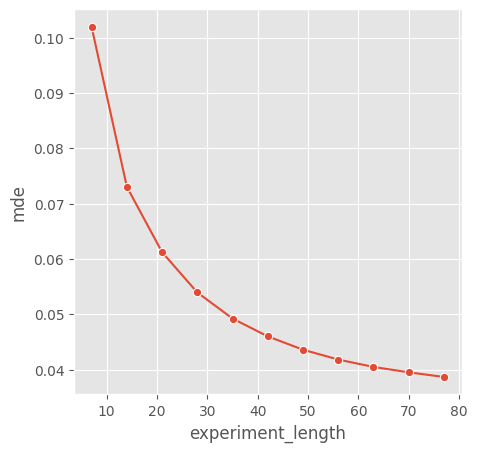

In [134]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.lineplot(
    data=mde_time_line_df,
    x='experiment_length',
    y='mde',
    marker='o'
)

<Axes: xlabel='experiment_length', ylabel='mde'>

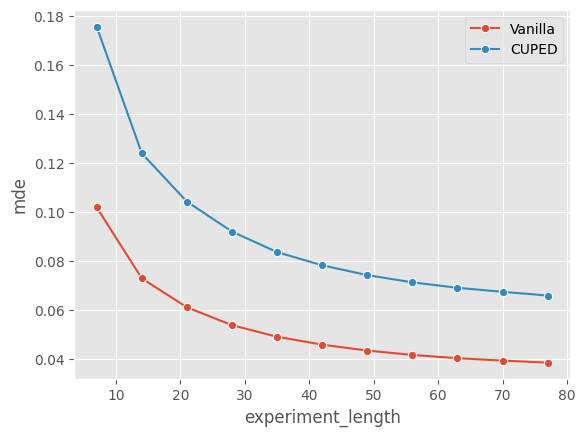

In [117]:
fig, ax = plt.subplots()
sns.lineplot(
    data=mde_time_line_df,
    x='experiment_length',
    y='mde',
    marker='o',
    label = 'Vanilla',
    ax = ax
)
sns.lineplot(
    data = cuped_mde_time_line_df,
    x = 'experiment_length',
     y='mde',
    marker='o',
    label = 'CUPED',
    ax = ax
)

# Analysis
Running the experiment for 30 days to detect ~1.5 EUR in AOV change.

In [25]:
splitter = ClusteredSplitter(
    cluster_cols=cluster_cols,
    treatment_col = 'variant',
    treatments = ['control', 'treatment']
)
experiment_analysis_data = (
    splitter
    .assign_treatment_df(
        df=(
            get_cupac_df(
                pre_df=experiment_design_data,
                post_df=_experiment_analysis_data,
                cluster_cols=cluster_cols
            )
        )
    )
)

    

In [26]:
metric_average_order_value = SimpleMetric(
    name = 'order_value',
    alias = 'AOV'
)

variants = [
    Variant(name='control', is_control=True),
    Variant(name='treatment', is_control=False)
]

In [27]:
test_order_value = HypothesisTest(
    metric=metric_average_order_value,
    analysis_type="clustered_ols",
    analysis_config={
        "cluster_cols":["customer_id"],
        'covariates': ['estimate_' + target_col]
    },
    cupac_config={
        'cupac_model': HistGradientBoostingRegressor(),
        'target_col': target_col,
        'features_cupac_model': feature_cols
    }
)

In [28]:
analysis_plan = AnalysisPlan(
    tests = [test_order_value],
    variants = variants,
    variant_col = 'variant',
    alpha = 0.05
)
display(
    analysis_plan.analyze(
        exp_data = experiment_analysis_data,
        pre_exp_data = get_cupac_df(
            post_df = experiment_design_data,
            pre_df = pre_experiment_data,
            cluster_cols=cluster_cols
        )
    )
    .to_dataframe()
    .T
)

,0
metric_alias,AOV
control_variant_name,control
treatment_variant_name,treatment
control_variant_mean,110.167036
treatment_variant_mean,109.466066
analysis_type,clustered_ols
ate,-0.591662
ate_ci_lower,-1.277353
ate_ci_upper,0.094028
p_value,0.090799


# Switchback

In [127]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
plt.style.use('ggplot')

from cluster_experiments import (
    SwitchbackSplitter,
    ConstantWashover,
    ConstantPerturbator,
    ClusteredOLSAnalysis,
    PowerAnalysis
)

In [123]:
target_col = 'order_value'
time_col = 'order_time'
average_effect = 1

In [121]:
experiment_design_data = (
    data
    .query('180 <= time_index < 270')
    .reset_index(drop=True)
)
print(f'{experiment_design_data.shape=}')

experiment_design_data.shape=(105315, 4)


In [133]:
washover = ConstantWashover(
    washover_time_delta = '30m'
)
splitter = SwitchbackSplitter(
    time_col = time_col,
    switch_frequency='1h',
    cluster_cols = ['order_time'],
    washover=washover
)
perturbator = ConstantPerturbator(
    target_col=target_col
)
analysis = ClusteredOLSAnalysis(
    cluster_cols=['order_time'],
    target_col=target_col
)
switchback_power_analysis = PowerAnalysis(
    splitter=splitter,
    perturbator=perturbator,
    analysis=analysis,
    target_col=target_col
)
switchback_power = switchback_power_analysis.power_analysis(
    df=experiment_design_data,
    average_effect= average_effect,
    n_simulations = 100,
    n_jobs=10
)
print(f'Estimated Power (Switchback): {switchback_power:.3f}')

Estimated Power (Switchback): 0.650


# Experiment Analysis

In [148]:
from sklearn.ensemble import HistGradientBoostingRegressor

from cluster_experiments import (
    ClusteredSplitter,
    NormalPerturbator,
    ClusteredOLSAnalysis,
    SimpleMetric,
    Variant,
    Dimension,
    HypothesisTest,
    AnalysisPlan
)

In [144]:
def get_cupac_df(
    pre_df:pd.DataFrame,
    post_df:pd.DataFrame,
    cluster_cols: list[str]
    ) -> pd.DataFrame:
    agg_pre_df = (
        pre_df
        .groupby(
            by = cluster_cols,
            as_index = False
        )
        .agg(
            pre_n_orders = ('order_time', 'count'),
            pre_aov = ('order_value', 'mean')
        )
    )
    cupac_df = (
        pd.merge(
            left = post_df,
            right = agg_pre_df,
            on = cluster_cols
        )
        .fillna(0)
    )
    return cupac_df

In [145]:
cluster_cols = ['customer_id']
feature_cols = [
    'pre_n_orders',
    'pre_aov'
]
target_col = 'order_value'
time_col = 'order_time'
average_effect = 1

In [146]:
pre_experiment_data = (
    data
    .query('90 <= time_index < 180')
    .reset_index(drop=True)
)
print(f'{pre_experiment_data.shape=}')

experiment_design_data = (
    data
    .query('180 <= time_index < 270')
    .reset_index(drop=True)
)
print(f'{experiment_design_data.shape=}')

_experiment_analysis_data = (
    data
    .query('270 <= time_index < 360')
    .reset_index(drop=True)
)
print(f'{_experiment_analysis_data.shape=}')

pre_experiment_data.shape=(105636, 4)
experiment_design_data.shape=(105315, 4)
_experiment_analysis_data.shape=(105149, 4)


In [147]:
city_assigner = ClusteredSplitter(
    cluster_cols=cluster_cols,
    treatment_col='city_code',
    treatments=['MAD', 'BCN'],
    splitter_weights=[0.7, 0.3]
)
treatment_assigner = ClusteredSplitter(
    cluster_cols=cluster_cols,
    treatment_col='variant',
    treatments=['A', 'B'],
)
treatment_perturbator = NormalPerturbator(
    target_col = target_col,
    treatment_col='variant',
    treatment='B',
    average_effect=1,
    scale=1
)
    
experiment_analysis_data = (
    _experiment_analysis_data
    .pipe(city_assigner.assign_treatment_df)
    .pipe(treatment_assigner.assign_treatment_df)
    .pipe(treatment_perturbator.perturbate)
)

In [ ]:
metric__order_value = SimpleMetric(
    alias = 'AOV',
    name = 'order_value'
)

dimension__city_code = Dimension(
    name = 'city_code',
    values = ['MAD', 'BCN'],
)

variant__control = Variant(
    name = 'A',
    is_control = True
)
variant__treatment = Variant(
    name = 'B',
    is_control = False
)

test__order_value = HypothesisTest(
    metric = metric__order_value,
    dimensions=[dimension__city_code],
    analysis_type = 'clustered_ols',
    analysis_config = {
        'target_col': target_col,
        'cluster_cols': cluster_cols,
        'covariates': ['estimate_' + target_col]
    },
    cupac_config = {
        'cupac_model': HistGradientBoostingRegressor(),
        'target_col': target_col,
        'features_cupac_model': feature_cols
    }
)

analysis_plan = AnalysisPlan(
    tests = [test__order_value],
    variants = [variant__control, variant__treatment],
    variant_col = 'variant',
    alpha = 0.05
)

analysis_results = (
    analysis_plan
    .analyze(
        exp_data = get_cupac_df(
            pre_df = experiment_design_data,
            post_df = experiment_analysis_data,
            cluster_cols=cluster_cols
        ),
        pre_exp_data = get_cupac_df(
            pre_df = pre_experiment_data,
            post_df = experiment_design_data,
            cluster_cols=cluster_cols
        )
    )
    .to_dataframe()
)   

  metric_alias control_variant_name treatment_variant_name  \
0          AOV                    A                      B   
1          AOV                    A                      B   
2          AOV                    A                      B   

   control_variant_mean  treatment_variant_mean  analysis_type       ate  \
0            109.232271              111.388832  clustered_ols  1.871505   
1            108.790304              110.966418  clustered_ols  1.677030   
2            110.262129              112.383112  clustered_ols  2.329852   

   ate_ci_lower  ate_ci_upper       p_value  std_error     dimension_name  \
0      1.187149      2.555861  8.326646e-08   0.349168  __total_dimension   
1      0.858332      2.495728  5.949345e-05   0.417711          city_code   
2      1.083194      3.576510  2.493428e-04   0.636062          city_code   

  dimension_value  alpha  
0           total   0.05  
1             MAD   0.05  
2             BCN   0.05  


In [157]:
analysis_results.to_csv()

',metric_alias,control_variant_name,treatment_variant_name,control_variant_mean,treatment_variant_mean,analysis_type,ate,ate_ci_lower,ate_ci_upper,p_value,std_error,dimension_name,dimension_value,alpha\n0,AOV,A,B,109.23227095707418,111.38883207389074,clustered_ols,1.871505182667863,1.1871490522494719,2.555861313086254,8.32664606675783e-08,0.3491677070683467,__total_dimension,total,0.05\n1,AOV,A,B,108.79030378408632,110.96641801469755,clustered_ols,1.6770298258639866,0.8583317447209258,2.4957279070070477,5.949345000016436e-05,0.41771077815758195,city_code,MAD,0.05\n2,AOV,A,B,110.26212940153601,112.38311185636742,clustered_ols,2.329851828135604,1.0831939155278363,3.576509740743372,0.0002493427858373159,0.6360616431940824,city_code,BCN,0.05\n'